## Pipeline Summary

This notebook extracts temporal features from the preprocessed split index and saves per-split `.pt` files. These features are used by models with FiLM conditioning (U-Net+FiLM, FNO v2, U-FNO) so they can account for storm lifecycle stage, time of day, and season.

**Prerequisite:** Run `data-preprocessing-pipeline.ipynb` first — this notebook reads the `split_index.csv` it produces.

- **Input:** `split_index.csv` from the data preprocessing pipeline, with one row per 6-hourly timestep.
- **Alignment:** The split index contains *all* timesteps from the raw TCND data, but the preprocessing pipeline drops timesteps with missing Data1D entries. This notebook replicates that filtering by loading the raw Data1D text files and keeping only timesteps that have a matching `(storm, datetime)` entry — ensuring the temporal features align exactly with the grid, env, data1d, and label tensors.
- **Features computed:** 6 temporal features per timestep — storm progress (0→1), cyclical hour-of-day (sin/cos), cyclical month (sin/cos), and normalised storm duration.
- **Output:** 5 `.pt` files (one per split), each mapping storm names to `(N_t, 6)` tensors. After filtering: 117 storms, 3,621 timesteps across all splits.
- **Why cyclical encoding?** If we fed raw hour or month values (e.g. 0–23), the model would think hour 23 and hour 0 are far apart, when they are actually adjacent. Sin/cos encoding places them next to each other on a circle.

## Section 0: Setup & Configuration

Import libraries and define file paths. The input is `split_index.csv` produced by the data preprocessing pipeline; the output goes to a `time/` subdirectory alongside the other processed data.

**Output:** File paths set; output directory created.

In [1]:
import math
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Paths ──
PROJECT_ROOT = Path.cwd().resolve().parent.parent
DATA_DIR = PROJECT_ROOT / "data" / "processed-data"
INDEX_PATH = DATA_DIR / "split_index.csv"
OUT_DIR = DATA_DIR / "time"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Raw TCND data (needed for Data1D filtering)
TCND_ROOT = PROJECT_ROOT / "data" / "tropicyclonenet" / "TCND_small_dataset" / "TCND_small_dataset"
BASINS = ["WP", "SP"]

# ── Constants ──
SPLIT_NAMES = ["wp_train", "wp_val", "sp_test", "sp_ft_train", "sp_ft_val"]
TWO_PI = 2.0 * math.pi
N_FEATURES = 6  # number of temporal features per timestep

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"TCND root:    {TCND_ROOT} (exists: {TCND_ROOT.exists()})")
print(f"Index file:   {INDEX_PATH} (exists: {INDEX_PATH.exists()})")
print(f"Output dir:   {OUT_DIR}")

Project root: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting
Data dir:     /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data
TCND root:    /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/tropicyclonenet/TCND_small_dataset/TCND_small_dataset (exists: True)
Index file:   /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data/split_index.csv (exists: True)
Output dir:   /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data/time


Confirms the split index file exists and the output directory is ready.

## Section 1: Load Split Index & Filter to Surviving Timesteps

The split index CSV contains *all* timesteps from the raw TCND data (161 storms, 5,484 timesteps). However, the data preprocessing pipeline drops timesteps where Data1D track data is missing — particularly for WP storms from 2020–2021 that are absent from the TCND test subset. We replicate that filtering here by loading the raw Data1D text files and keeping only `(storm, datetime)` pairs that have a matching entry.

**Output:** `df` DataFrame filtered to only surviving timesteps, aligned with the label/grid/env/data1d `.pt` files.

In [2]:
# ── 1a: Load split index ──
df_raw = pd.read_csv(INDEX_PATH)
df_raw = df_raw.sort_values(["split", "storm", "datetime"]).reset_index(drop=True)
df_raw["datetime"] = df_raw["datetime"].astype(str)

print(f"Raw split index: {len(df_raw)} rows, {df_raw['storm'].nunique()} storms")

# ── 1b: Load Data1D text files to build (storm_name, datetime) lookup ──
DATA1D_COLS = ["index", "category", "lat_offset", "lon_offset",
               "wind_norm", "pressure_norm", "datetime", "name"]

data1d_datetimes = set()  # set of (data1d_storm_name, datetime_str)
data1d_all_names = []

for basin in BASINS:
    d1d_dir = TCND_ROOT / "Data1D" / basin / "test"
    for f in sorted(d1d_dir.glob("*.txt")):
        storm_name = f.stem  # e.g. WP2017BSTBANYAN
        d1d_df = pd.read_csv(f, sep="\t", header=None, names=DATA1D_COLS, dtype={"datetime": str})
        data1d_all_names.append(storm_name)
        for dt in d1d_df["datetime"].str.strip():
            data1d_datetimes.add((storm_name, dt))

print(f"Data1D lookup: {len(data1d_datetimes)} (storm, datetime) entries from {len(data1d_all_names)} storms")

# ── 1c: Build storm name mapping (split_index storm → Data1D storm) ──
# Data1D files are named like "WP2017BSTBANYAN", split_index has storm="BANYAN", basin="WP"
def find_data1d_storm(storm_name, basin):
    """Find the Data1D key matching a storm from the split index."""
    candidates = [k for k in data1d_all_names if storm_name in k and k.startswith(basin)]
    return candidates[0] if candidates else None

storm_name_map = {}
for _, row in df_raw[["basin", "storm"]].drop_duplicates().iterrows():
    storm_name_map[(row["basin"], row["storm"])] = find_data1d_storm(row["storm"], row["basin"])

# ── 1d: Filter split index to surviving timesteps ──
keep_mask = []
for _, row in df_raw.iterrows():
    d1d_name = storm_name_map.get((row["basin"], row["storm"]))
    dt = str(row["datetime"]).strip()
    keep_mask.append(d1d_name is not None and (d1d_name, dt) in data1d_datetimes)

df = df_raw[keep_mask].reset_index(drop=True)

print(f"\nAfter Data1D filtering: {len(df)} rows, {df['storm'].nunique()} storms")
print(f"Dropped: {len(df_raw) - len(df)} timesteps ({len(df_raw) - len(df):.0f}/{len(df_raw):.0f})")

# ── Per-split summary ──
print()
split_summary = df.groupby("split").agg(
    storms=("storm", "nunique"),
    timesteps=("datetime", "count"),
).reindex(SPLIT_NAMES)
print(split_summary.to_string())
print(f"\nTotal: {split_summary['storms'].sum()} storms, {split_summary['timesteps'].sum()} timesteps")

Raw split index: 5484 rows, 161 storms
Data1D lookup: 5484 (storm, datetime) entries from 175 storms

After Data1D filtering: 3621 rows, 117 storms
Dropped: 1863 timesteps (1863/5484)

             storms  timesteps
split                         
wp_train         69       2092
wp_val           18        607
sp_test          15        427
sp_ft_train      12        402
sp_ft_val         3         93

Total: 117 storms, 3621 timesteps


After filtering, the counts should match the data preprocessing pipeline output: **117 storms, 3,621 timesteps** total. The drops are concentrated in WP (2020–2021 storms missing from the TCND test subset's Data1D directory). SP splits are unaffected.

## Section 2: Feature Extraction

For each storm, compute a `(N_t, 6)` tensor of temporal features from the datetime strings:

| Index | Feature | Formula | What it captures |
|-------|---------|---------|-----------------|
| 0 | `storm_progress` | $i / (N_t - 1)$ | How far through its lifecycle the storm is (0 = start, 1 = end) |
| 1 | `hour_sin` | $\sin(2\pi \cdot h / 24)$ | Time of day (sin component) |
| 2 | `hour_cos` | $\cos(2\pi \cdot h / 24)$ | Time of day (cos component) |
| 3 | `month_sin` | $\sin(2\pi \cdot (m-1) / 12)$ | Season (sin component) |
| 4 | `month_cos` | $\cos(2\pi \cdot (m-1) / 12)$ | Season (cos component) |
| 5 | `storm_duration_norm` | $N_t / N_{\max}$ | How long-lived the storm is relative to the longest storm in the dataset (constant across timesteps within a storm) |

We need both sin and cos for each cyclical feature because sin alone is ambiguous (e.g. sin is the same for hour 6 and hour 18). The pair together gives a unique position on the circle.

Feature 5 (`storm_duration_norm`) is distinct from feature 0 (`storm_progress`): progress tells the model *where* in the storm lifecycle this timestep is, while duration tells it *how long-lived* the storm is overall. Longer storms tend to be more intense, so this gives the model a useful structural signal.

**Output:** `all_time_dicts` — dictionary mapping split names to `{storm_name: tensor(N_t, 6)}`.

In [3]:
def parse_datetime(dt_str: str):
    """Parse YYYYMMDDhh string into (month, hour)."""
    s = str(dt_str)
    month = int(s[4:6])
    hour = int(s[8:10])
    return month, hour


def build_time_features(group_df: pd.DataFrame, max_storm_len: int) -> torch.Tensor:
    """Build (N_t, 6) tensor for one storm from its rows (already sorted)."""
    n = len(group_df)
    feats = torch.zeros(n, N_FEATURES)
    duration_norm = n / max(max_storm_len, 1)

    for i, (_, row) in enumerate(group_df.iterrows()):
        month, hour = parse_datetime(row["datetime"])

        # storm_progress: 0.0 at start, 1.0 at end
        progress = i / max(n - 1, 1)

        # hour cyclical (period = 24)
        hour_sin = math.sin(TWO_PI * hour / 24.0)
        hour_cos = math.cos(TWO_PI * hour / 24.0)

        # month cyclical (period = 12)
        month_sin = math.sin(TWO_PI * (month - 1) / 12.0)
        month_cos = math.cos(TWO_PI * (month - 1) / 12.0)

        feats[i] = torch.tensor([
            progress, hour_sin, hour_cos, month_sin, month_cos, duration_norm
        ])

    return feats


# ── Compute max storm length across all splits (for normalisation) ──
max_storm_len = df.groupby(["split", "storm"]).size().max()
print(f"Max storm length across dataset: {max_storm_len} timesteps")

# ── Extract features for all splits ──
all_time_dicts = {}

print(f"\n{'Split':>15s}  {'Storms':>6s}  {'Timesteps':>9s}")
print("-" * 36)

for split in SPLIT_NAMES:
    split_df = df[df["split"] == split]
    if split_df.empty:
        print(f"{split:>15s}: no rows found, skipping")
        continue

    time_dict = {}
    for storm_name, storm_df in split_df.groupby("storm", sort=False):
        storm_df_sorted = storm_df.sort_values("datetime")
        time_dict[storm_name] = build_time_features(storm_df_sorted, max_storm_len)

    all_time_dicts[split] = time_dict

    total_ts = sum(v.shape[0] for v in time_dict.values())
    print(f"{split:>15s}  {len(time_dict):6d}  {total_ts:9d}")

total_storms = sum(len(d) for d in all_time_dicts.values())
total_ts = sum(v.shape[0] for d in all_time_dicts.values() for v in d.values())
print("-" * 36)
print(f"{'Total':>15s}  {total_storms:6d}  {total_ts:9d}")

Max storm length across dataset: 82 timesteps

          Split  Storms  Timesteps
------------------------------------
       wp_train      69       2092
         wp_val      18        607
        sp_test      15        427
    sp_ft_train      12        402
      sp_ft_val       3         93
------------------------------------
          Total     117       3621


After Data1D filtering, the counts should match the preprocessing pipeline: **117 storms, 3,621 timesteps**. Each tensor has shape `(N_t, 6)` where `N_t` varies per storm — typically 10–80 timesteps for a multi-day cyclone. Feature 5 (`storm_duration_norm`) is constant within each storm but varies across storms, giving the model a structural signal about storm longevity.

## Section 3: Feature Distribution Visualisation

Plot histograms of all 6 features to check they look reasonable. Sin/cos features should range from -1 to 1; progress should range from 0 to 1.

**Output:** Histograms and summary statistics for all temporal features.

Total feature tensor shape: torch.Size([3621, 6])

Per-feature statistics:
  storm_progress             min=0.000  max=1.000  mean=0.500  std=0.298
  hour_sin                   min=-1.000  max=1.000  mean=0.006  std=0.705
  hour_cos                   min=-1.000  max=1.000  mean=0.008  std=0.709
  month_sin                  min=-1.000  max=1.000  mean=-0.222  std=0.643
  month_cos                  min=-1.000  max=1.000  mean=-0.134  std=0.721
  storm_duration_norm        min=0.122  max=1.000  mean=0.429  std=0.152


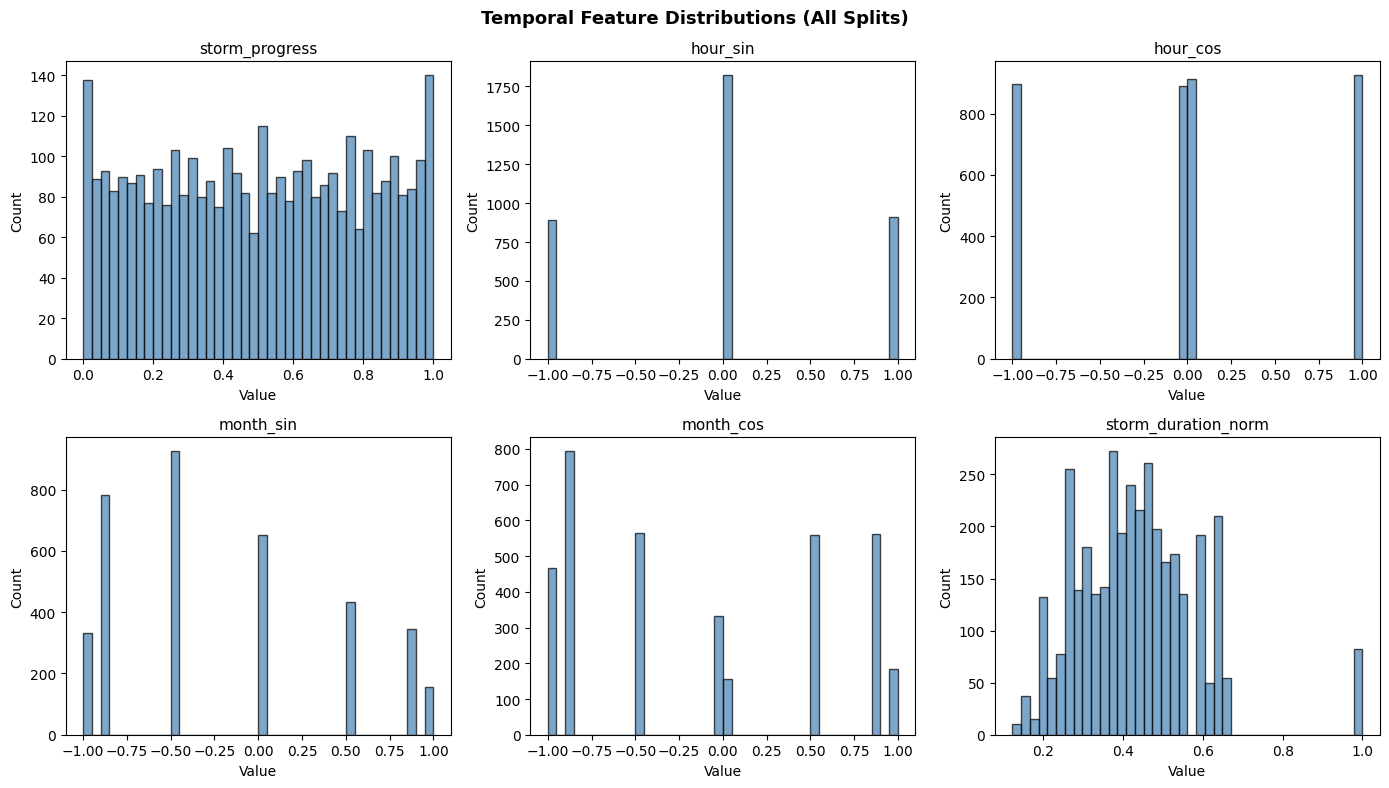

In [4]:
# Concatenate all features for visualisation
all_feats = torch.cat([v for d in all_time_dicts.values() for v in d.values()], dim=0)
feature_names = ["storm_progress", "hour_sin", "hour_cos", "month_sin", "month_cos", "storm_duration_norm"]

print(f"Total feature tensor shape: {all_feats.shape}")
print(f"\nPer-feature statistics:")
for i, name in enumerate(feature_names):
    vals = all_feats[:, i]
    print(f"  {name:25s}  min={vals.min():.3f}  max={vals.max():.3f}  mean={vals.mean():.3f}  std={vals.std():.3f}")

# ── Histograms ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (ax, name) in enumerate(zip(axes.flat, feature_names)):
    vals = all_feats[:, i].numpy()
    ax.hist(vals, bins=40, edgecolor="black", alpha=0.7, color="steelblue")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
fig.suptitle("Temporal Feature Distributions (All Splits)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The hour histograms should show only 4 distinct values (00, 06, 12, 18 UTC) since observations are 6-hourly. The month distribution reflects cyclone seasons — WP is most active Jul–Nov, SP is most active Dec–Apr. The `storm_duration_norm` histogram shows the distribution of storm lengths: most storms are short-to-medium, with a long tail of long-lived storms.

## Section 4: Cyclical Encoding Verification

Plot the hour and month features on polar axes to visually confirm the cyclical encoding works — points should sit on a circle with no gaps or jumps.

**Output:** Polar scatter plots for hour-of-day and month-of-year.

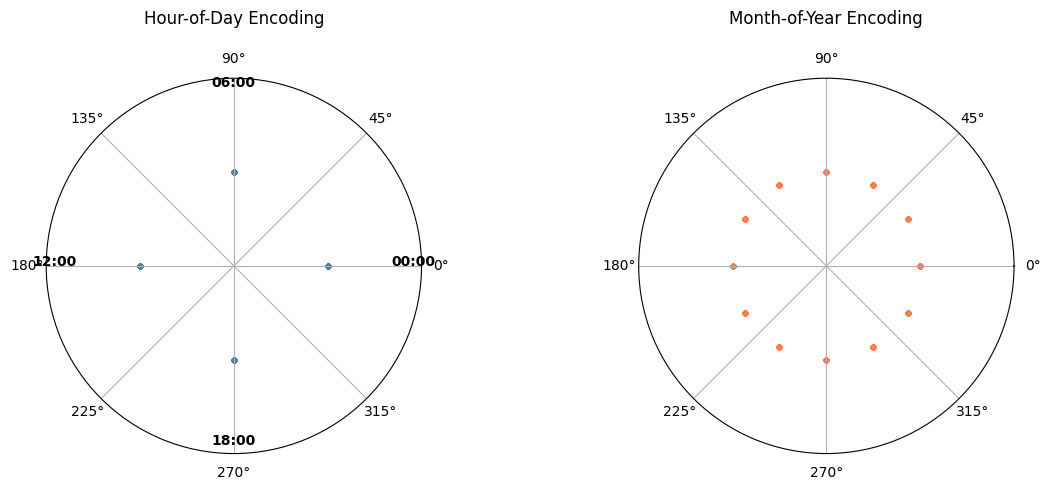

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": "polar"})

# ── Hour-of-day ──
hour_angles = np.arctan2(all_feats[:, 1].numpy(), all_feats[:, 2].numpy())  # atan2(sin, cos)
hour_labels = ((hour_angles / TWO_PI * 24) % 24).astype(int)
ax1.scatter(hour_angles, np.ones_like(hour_angles), c="steelblue", alpha=0.3, s=10)
ax1.set_title("Hour-of-Day Encoding", pad=20, fontsize=12)
ax1.set_rticks([])
# Label the 4 observation hours
for h in [0, 6, 12, 18]:
    angle = TWO_PI * h / 24.0
    ax1.annotate(f"{h:02d}:00", xy=(angle, 1.05), ha="center", fontsize=10, fontweight="bold")

# ── Month-of-year ──
month_angles = np.arctan2(all_feats[:, 3].numpy(), all_feats[:, 4].numpy())
ax2.scatter(month_angles, np.ones_like(month_angles), c="coral", alpha=0.3, s=10)
ax2.set_title("Month-of-Year Encoding", pad=20, fontsize=12)
ax2.set_rticks([])
# Label months
month_abbr = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
for m in range(12):
    angle = TWO_PI * m / 12.0
    ax2.annotate(month_abbr[m], xy=(angle, 1.08), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

The hour plot should show exactly 4 clusters at 00, 06, 12, and 18 UTC. The month plot should show where cyclone activity is concentrated — and importantly, December and January should be next to each other on the circle (not 11 months apart, which is what would happen with raw month numbers).

## Section 5: Save to Disk

Save each split's temporal features as a `.pt` file. The file structure matches the grid, env, data1d, and label files from the preprocessing pipeline — a dictionary mapping storm names to tensors.

**Output:** `time/{split}_time.pt` for all 5 splits, saved to `data/processed-data/`.

In [6]:
for split in SPLIT_NAMES:
    time_dict = all_time_dicts[split]
    out_path = OUT_DIR / f"{split}_time.pt"
    torch.save(time_dict, out_path)

    total_ts = sum(v.shape[0] for v in time_dict.values())
    print(f"Saved: {out_path}  ({len(time_dict)} storms, {total_ts} timesteps)")

Saved: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data/time/wp_train_time.pt  (69 storms, 2092 timesteps)
Saved: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data/time/wp_val_time.pt  (18 storms, 607 timesteps)
Saved: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data/time/sp_test_time.pt  (15 storms, 427 timesteps)
Saved: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data/time/sp_ft_train_time.pt  (12 storms, 402 timesteps)
Saved: /root/climate-change-group-project/Yasmin Drafts/cross-basin-cyclone-forecasting/data/processed-data/time/sp_ft_val_time.pt  (3 storms, 93 timesteps)


Model code loads these files with `torch.load()` and looks up each storm by name, so the temporal features stay aligned with the other modalities automatically.

## Section 6: Sanity Checks

Reload the saved files and verify that (1) tensor shapes are correct, (2) there are no NaN/Inf values, and (3) storm names and timestep counts match the label files from the preprocessing pipeline.

**Output:** Pass/fail for all 5 splits.

In [7]:
print("=" * 60)
print("SANITY CHECKS")
print("=" * 60)

all_ok = True
for split in SPLIT_NAMES:
    time_dict = torch.load(OUT_DIR / f"{split}_time.pt", weights_only=False)
    
    # Check tensor shapes
    for storm, tensor in time_dict.items():
        if tensor.dim() != 2 or tensor.shape[1] != N_FEATURES:
            print(f"  FAIL: {split}/{storm} has shape {tensor.shape}, expected (N_t, {N_FEATURES})")
            all_ok = False
        if torch.isnan(tensor).any() or torch.isinf(tensor).any():
            print(f"  FAIL: {split}/{storm} contains NaN/Inf values")
            all_ok = False
    
    # Cross-check with labels if available
    labels_path = DATA_DIR / "labels" / f"{split}_labels.pt"
    if labels_path.exists():
        labels = torch.load(labels_path, weights_only=False)
        missing = set(labels.keys()) - set(time_dict.keys())
        extra = set(time_dict.keys()) - set(labels.keys())
        if missing:
            print(f"  FAIL: {split} — storms in labels but not in time: {missing}")
            all_ok = False
        if extra:
            print(f"  FAIL: {split} — storms in time but not in labels: {extra}")
            all_ok = False
        for storm in time_dict:
            if storm in labels:
                nt_time = time_dict[storm].shape[0]
                nt_label = labels[storm]["direction"].shape[0]
                if nt_time != nt_label:
                    print(f"  FAIL: {split}/{storm} — time has {nt_time} timesteps, labels has {nt_label}")
                    all_ok = False
        del labels
    
    n_storms = len(time_dict)
    n_ts = sum(v.shape[0] for v in time_dict.values())
    print(f"  {split:15s}: {n_storms:3d} storms, {n_ts:5d} timesteps — per-storm tensor: (Nt, {N_FEATURES})  ✓")

print()
if all_ok:
    print("All checks passed.")
else:
    print("SOME CHECKS FAILED — see above.")

SANITY CHECKS
  wp_train       :  69 storms,  2092 timesteps — per-storm tensor: (Nt, 6)  ✓
  wp_val         :  18 storms,   607 timesteps — per-storm tensor: (Nt, 6)  ✓
  sp_test        :  15 storms,   427 timesteps — per-storm tensor: (Nt, 6)  ✓
  sp_ft_train    :  12 storms,   402 timesteps — per-storm tensor: (Nt, 6)  ✓
  sp_ft_val      :   3 storms,    93 timesteps — per-storm tensor: (Nt, 6)  ✓

All checks passed.


All checks should now pass — the Data1D filtering in Section 1 ensures that the temporal features contain exactly the same storms and timestep counts as the label files. If any checks fail, it indicates a mismatch between the Data1D filtering logic here and the preprocessing pipeline, which should be investigated.